# BI-Projekt: Veloverkehr in Schweizer Städten

## 1 – Datenakquisition & erste Exploration

Dieses Notebook lädt die Kerndatensätze herunter und führt eine erste Sichtung durch.

**Datenquellen:**
- Velozählstellen Zürich (15-Min, data.stadt-zuerich.ch)
- Velozähldaten Basel (stündlich, data.bs.ch)
- Velozählungen St. Gallen (Tagesaggregation, daten.stadt.sg.ch)
- MeteoSwiss Wetterdaten (Station Zürich/Fluntern)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.figsize'] = (14, 6)

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

print('Setup OK')

Setup OK


---
## 1.1 Zürich – Velo-/Fussgängerzählungen (15-Min)

In [2]:
# Download Zürich data – one CSV per year
# Available from 2009-2026 at data.stadt-zuerich.ch
ZH_BASE = 'https://data.stadt-zuerich.ch/dataset/ted_taz_verkehrszaehlungen_werte_fussgaenger_velo/download'
ZH_YEARS = range(2020, 2026)  # start with recent years; extend to 2009 if needed

for year in ZH_YEARS:
    fname = f'{year}_verkehrszaehlungen_werte_fussgaenger_velo.csv'
    fpath = DATA_DIR / fname
    if not fpath.exists():
        url = f'{ZH_BASE}/{fname}'
        print(f'Downloading {fname} ...')
        r = requests.get(url, timeout=120)
        r.raise_for_status()
        fpath.write_bytes(r.content)
        print(f'  -> {fpath} ({len(r.content) / 1e6:.1f} MB)')
    else:
        print(f'{fname} already exists')

  -> data\2020_verkehrszaehlungen_werte_fussgaenger_velo.csv (56.9 MB)


  -> data\2021_verkehrszaehlungen_werte_fussgaenger_velo.csv (53.4 MB)


  -> data\2022_verkehrszaehlungen_werte_fussgaenger_velo.csv (54.0 MB)


  -> data\2023_verkehrszaehlungen_werte_fussgaenger_velo.csv (43.1 MB)


  -> data\2024_verkehrszaehlungen_werte_fussgaenger_velo.csv (41.7 MB)


  -> data\2025_verkehrszaehlungen_werte_fussgaenger_velo.csv (38.8 MB)


In [3]:
# Load and concatenate Zürich data
zh_frames = []
for year in ZH_YEARS:
    fname = f'{year}_verkehrszaehlungen_werte_fussgaenger_velo.csv'
    df = pd.read_csv(DATA_DIR / fname)
    zh_frames.append(df)
    print(f'{year}: {len(df):>10,} rows, columns: {list(df.columns)}')

zh = pd.concat(zh_frames, ignore_index=True)
print(f'\nTotal Zürich: {len(zh):,} rows')
zh.head()

2020:  1,257,695 rows, columns: ['FK_STANDORT', 'DATUM', 'VELO_IN', 'VELO_OUT', 'FUSS_IN', 'FUSS_OUT', 'OST', 'NORD']


2021:  1,178,570 rows, columns: ['FK_STANDORT', 'DATUM', 'VELO_IN', 'VELO_OUT', 'FUSS_IN', 'FUSS_OUT', 'OST', 'NORD']


2022:  1,189,238 rows, columns: ['FK_STANDORT', 'DATUM', 'VELO_IN', 'VELO_OUT', 'FUSS_IN', 'FUSS_OUT', 'OST', 'NORD']


2023:    949,660 rows, columns: ['FK_STANDORT', 'DATUM', 'VELO_IN', 'VELO_OUT', 'FUSS_IN', 'FUSS_OUT', 'OST', 'NORD']


2024:    918,683 rows, columns: ['FK_STANDORT', 'DATUM', 'VELO_IN', 'VELO_OUT', 'FUSS_IN', 'FUSS_OUT', 'OST', 'NORD']


2025:    853,565 rows, columns: ['FK_STANDORT', 'DATUM', 'VELO_IN', 'VELO_OUT', 'FUSS_IN', 'FUSS_OUT', 'OST', 'NORD']

Total Zürich: 6,347,411 rows


,FK_STANDORT,DATUM,VELO_IN,VELO_OUT,FUSS_IN,FUSS_OUT,OST,NORD
0,3927,2020-01-01T00:00,1.0,1.0,NaN,NaN,2682873,1245891
1,2977,2020-01-01T00:00,1.0,NaN,NaN,NaN,2682681,1250570
2,3923,2020-01-01T00:00,0.0,0.0,NaN,NaN,2681385,1247736
3,2979,2020-01-01T00:00,0.0,0.0,NaN,NaN,2681858,1251991
4,60,2020-01-01T00:00,0.0,0.0,NaN,NaN,2682731,1247708


In [4]:
zh.info()
print('\n--- Descriptive Stats ---')
zh.describe()

<class 'pandas.DataFrame'>
RangeIndex: 6347411 entries, 0 to 6347410
Data columns (total 8 columns):
 #   Column       Dtype  
---  ------       -----  
 0   FK_STANDORT  int64  
 1   DATUM        str    
 2   VELO_IN      float64
 3   VELO_OUT     float64
 4   FUSS_IN      float64
 5   FUSS_OUT     float64
 6   OST          int64  
 7   NORD         int64  
dtypes: float64(4), int64(3), str(1)
memory usage: 387.4 MB

--- Descriptive Stats ---


,FK_STANDORT,VELO_IN,VELO_OUT,FUSS_IN,FUSS_OUT,OST,NORD
count,6.347411e+06,4.499675e+06,3.926686e+06,1.854072e+06,1.854072e+06,6.347411e+06,6.347411e+06
mean,2.993860e+03,9.625092e+00,6.051418e+00,1.457134e+01,1.221276e+01,2.682510e+06,1.248489e+06
std,1.235721e+03,1.462709e+01,8.680143e+00,2.182167e+01,1.860218e+01,1.083600e+03,1.977933e+03
min,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.678956e+06,1.244136e+06
25%,2.978000e+03,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,2.682227e+06,1.247199e+06
50%,2.998000e+03,4.000000e+00,3.000000e+00,6.000000e+00,5.000000e+00,2.682731e+06,1.248328e+06
75%,4.242000e+03,1.200000e+01,9.000000e+00,2.000000e+01,1.700000e+01,2.683404e+06,1.249212e+06
max,5.004000e+03,1.086000e+03,6.870000e+02,6.860000e+02,6.620000e+02,2.684578e+06,1.253280e+06


---
## 1.2 Basel – Velo-/Fussgängerzählungen (stündlich)

In [5]:
# Basel: full processed dataset from data-bs.ch
BS_URL = 'https://data-bs.ch/mobilitaet/converted_Velo_Fuss_Count.csv'
BS_FILE = DATA_DIR / 'basel_velo_fuss_count.csv'

if not BS_FILE.exists():
    print('Downloading Basel data ...')
    r = requests.get(BS_URL, timeout=120)
    r.raise_for_status()
    BS_FILE.write_bytes(r.content)
    print(f'  -> {BS_FILE} ({len(r.content) / 1e6:.1f} MB)')
else:
    print('Basel data already exists')

  -> data\basel_velo_fuss_count.csv (1270.2 MB)


In [6]:
bs = pd.read_csv(BS_FILE, sep=';')  # Basel often uses semicolon delimiter
print(f'Basel: {len(bs):,} rows')
print(f'Columns: {list(bs.columns)}')
bs.head()

Basel: 8,337,600 rows
Columns: ['SiteCode', 'SiteName', 'DirectionName', 'LaneCode', 'LaneName', 'Date', 'TimeFrom', 'TimeTo', 'ValuesApproved', 'ValuesEdited', 'TrafficType', 'Total', 'DateTimeFrom', 'DateTimeTo', 'Year', 'Month', 'Day', 'Weekday', 'HourFrom', 'DayOfYear', 'Zst_id']


,SiteCode,SiteName,DirectionName,LaneCode,LaneName,Date,TimeFrom,TimeTo,ValuesApproved,ValuesEdited,...,Total,DateTimeFrom,DateTimeTo,Year,Month,Day,Weekday,HourFrom,DayOfYear,Zst_id
0,350,350 Dreirosenbrücke,1 nach Kleinbasel,7.0,Spur 7,01.12.2012,00:00,01:00,1,0,...,20,2012-12-01 00:00:00,2012-12-01 01:00:00,2012,12,1,5,0,336,350
1,350,350 Dreirosenbrücke,1 nach Kleinbasel,7.0,Spur 7,01.12.2012,01:00,02:00,1,0,...,13,2012-12-01 01:00:00,2012-12-01 02:00:00,2012,12,1,5,1,336,350
2,350,350 Dreirosenbrücke,1 nach Kleinbasel,7.0,Spur 7,01.12.2012,02:00,03:00,1,0,...,11,2012-12-01 02:00:00,2012-12-01 03:00:00,2012,12,1,5,2,336,350
3,350,350 Dreirosenbrücke,1 nach Kleinbasel,7.0,Spur 7,01.12.2012,03:00,04:00,1,0,...,10,2012-12-01 03:00:00,2012-12-01 04:00:00,2012,12,1,5,3,336,350
4,350,350 Dreirosenbrücke,1 nach Kleinbasel,7.0,Spur 7,01.12.2012,04:00,05:00,1,0,...,1,2012-12-01 04:00:00,2012-12-01 05:00:00,2012,12,1,5,4,336,350


In [7]:
bs.info()
print('\n--- Descriptive Stats ---')
bs.describe()

<class 'pandas.DataFrame'>
RangeIndex: 8337600 entries, 0 to 8337599
Data columns (total 21 columns):
 #   Column          Dtype  
---  ------          -----  
 0   SiteCode        int64  
 1   SiteName        str    
 2   DirectionName   str    
 3   LaneCode        float64
 4   LaneName        str    
 5   Date            str    
 6   TimeFrom        str    
 7   TimeTo          str    
 8   ValuesApproved  int64  
 9   ValuesEdited    int64  
 10  TrafficType     str    
 11  Total           int64  
 12  DateTimeFrom    str    
 13  DateTimeTo      str    
 14  Year            int64  
 15  Month           int64  
 16  Day             int64  
 17  Weekday         int64  
 18  HourFrom        int64  
 19  DayOfYear       int64  
 20  Zst_id          int64  
dtypes: float64(1), int64(11), str(9)
memory usage: 1.3 GB

--- Descriptive Stats ---


,SiteCode,LaneCode,ValuesApproved,ValuesEdited,Total,Year,Month,Day,Weekday,HourFrom,DayOfYear,Zst_id
count,8.337600e+06,7.835880e+06,8.337600e+06,8.337600e+06,8.337600e+06,8.337600e+06,8.337600e+06,8.337600e+06,8.337600e+06,8.337600e+06,8.337600e+06,8.337600e+06
mean,7.692970e+02,3.150051e+00,9.984139e-01,1.348602e-02,5.542346e+01,2.017975e+03,6.503227e+00,1.570821e+01,2.999666e+00,1.150000e+01,1.825265e+02,7.692970e+02
std,1.909220e+02,2.780946e+00,3.979388e-02,1.153436e-01,1.053243e+02,5.665270e+00,3.492715e+00,8.802901e+00,2.000132e+00,6.922187e+00,1.068012e+02,1.909220e+02
min,3.500000e+02,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+03,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,3.500000e+02
25%,6.600000e+02,1.000000e+00,1.000000e+00,0.000000e+00,3.000000e+00,2.015000e+03,3.000000e+00,8.000000e+00,1.000000e+00,5.750000e+00,8.800000e+01,6.600000e+02
50%,8.140000e+02,2.000000e+00,1.000000e+00,0.000000e+00,2.100000e+01,2.019000e+03,7.000000e+00,1.600000e+01,3.000000e+00,1.150000e+01,1.830000e+02,8.140000e+02
75%,9.090000e+02,7.000000e+00,1.000000e+00,0.000000e+00,6.500000e+01,2.022000e+03,1.000000e+01,2.300000e+01,5.000000e+00,1.725000e+01,2.760000e+02,9.090000e+02
max,9.990000e+02,8.000000e+00,1.000000e+00,1.000000e+00,4.148000e+03,2.026000e+03,1.200000e+01,3.100000e+01,6.000000e+00,2.300000e+01,3.660000e+02,9.990000e+02


---
## 1.3 St. Gallen – Velozählungen (Tagesaggregation)

In [8]:
# St. Gallen: daily aggregation from daten.stadt.sg.ch
SG_URL = 'https://daten.stadt.sg.ch/api/explore/v2.1/catalog/datasets/velozahlungen-stadt-stgallen-tagesaggregation/exports/csv?delimiter=%3B'
SG_FILE = DATA_DIR / 'sg_velo_daily.csv'

if not SG_FILE.exists():
    print('Downloading St. Gallen data ...')
    r = requests.get(SG_URL, timeout=120)
    r.raise_for_status()
    SG_FILE.write_bytes(r.content)
    print(f'  -> {SG_FILE} ({len(r.content) / 1e6:.1f} MB)')
else:
    print('St. Gallen data already exists')

  -> data\sg_velo_daily.csv (3.6 MB)


In [9]:
sg = pd.read_csv(SG_FILE, sep=';')
print(f'St. Gallen: {len(sg):,} rows')
print(f'Columns: {list(sg.columns)}')
sg.head()

St. Gallen: 35,227 rows
Columns: ['datum', 'bezeichnung', 'standort', 'arbeitstag', 'wochentag', 'tag_nr', 'kennzahl', 'anzahl_velos']


,datum,bezeichnung,standort,arbeitstag,wochentag,tag_nr,kennzahl,anzahl_velos
0,2019-01-08,Vadianstrasse 8,"47.422903, 9.372979",Werktage,Dienstag,2,"Tagesverkehr,Werktagsverkehr",367
1,2019-02-05,Oberstrasse 149,"47.414179, 9.356962",Werktage,Dienstag,2,"Tagesverkehr,Werktagsverkehr",82
2,2019-02-26,Rosenbergstrasse Veloweg,"47.421245, 9.359067",Werktage,Dienstag,2,"Tagesverkehr,Werktagsverkehr",418
3,2019-02-05,Splügenweg / Olma,"47.433074, 9.38514",Werktage,Dienstag,2,"Tagesverkehr,Werktagsverkehr",97
4,2019-02-19,Splügenweg / Olma,"47.433074, 9.38514",Werktage,Dienstag,2,"Tagesverkehr,Werktagsverkehr",203


In [10]:
sg.info()
print('\n--- Descriptive Stats ---')
sg.describe()

<class 'pandas.DataFrame'>
RangeIndex: 35227 entries, 0 to 35226
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   datum         35227 non-null  str  
 1   bezeichnung   35227 non-null  str  
 2   standort      35227 non-null  str  
 3   arbeitstag    35227 non-null  str  
 4   wochentag     35227 non-null  str  
 5   tag_nr        35227 non-null  int64
 6   kennzahl      35227 non-null  str  
 7   anzahl_velos  35227 non-null  int64
dtypes: int64(2), str(6)
memory usage: 2.2 MB

--- Descriptive Stats ---


,tag_nr,anzahl_velos
count,35227.000000,35227.000000
mean,3.997814,400.727908
std,2.001042,349.786367
min,1.000000,0.000000
25%,2.000000,163.000000
50%,4.000000,307.000000
75%,6.000000,528.000000
max,7.000000,2892.000000


---
## 1.4 MeteoSwiss – Wetterdaten (Zürich/Fluntern)

MeteoSwiss publishes open data at `data.geo.admin.ch`.  
Station **SMA** (lowercase `sma` in URLs) = Zürich/Fluntern – the main reference station for Zürich.  
We fetch hourly measurements (temperature, precipitation, wind, sunshine).

In [11]:
# MeteoSwiss: direct download for station sma (Zürich/Fluntern) hourly data
# Two files: historical (2020-2029 decade) and recent/now
METEO_BASE = 'https://data.geo.admin.ch/ch.meteoschweiz.ogd-smn/sma'
METEO_FILES = {
    'meteo_sma_h_2020_2029.csv': f'{METEO_BASE}/ogd-smn_sma_h_historical_2020-2029.csv',
    'meteo_sma_h_now.csv': f'{METEO_BASE}/ogd-smn_sma_h_now.csv',
}

for fname, url in METEO_FILES.items():
    fpath = DATA_DIR / fname
    if not fpath.exists():
        print(f'Downloading {fname} ...')
        r = requests.get(url, timeout=120)
        r.raise_for_status()
        fpath.write_bytes(r.content)
        print(f'  -> {fpath} ({len(r.content) / 1e6:.1f} MB)')
    else:
        print(f'{fname} already exists')

  -> data\meteo_sma_h_2020_2029.csv (7.1 MB)
  -> data\meteo_sma_h_now.csv (0.0 MB)


In [12]:
# Load and concatenate MeteoSwiss hourly data
meteo_frames = []
for fname in METEO_FILES:
    fpath = DATA_DIR / fname
    if fpath.exists():
        df = pd.read_csv(fpath, sep=';')
        meteo_frames.append(df)
        print(f'{fname}: {len(df):,} rows')

if meteo_frames:
    meteo = pd.concat(meteo_frames, ignore_index=True).drop_duplicates()
    print(f'\nTotal MeteoSwiss: {len(meteo):,} rows')
    print(f'Columns: {list(meteo.columns)}')
    display(meteo.head())
else:
    print('No MeteoSwiss files found – check downloads above')

meteo_sma_h_2020_2029.csv: 52,608 rows
meteo_sma_h_now.csv: 2 rows

Total MeteoSwiss: 52,610 rows
Columns: ['station_abbr', 'reference_timestamp', 'tre200h0', 'tre200hn', 'tre200hx', 'tre005h0', 'tre005hn', 'ure200h0', 'pva200h0', 'tde200h0', 'prestah0', 'pp0qffh0', 'pp0qnhh0', 'ppz700h0', 'ppz850h0', 'fkl010h1', 'dkl010h0', 'fkl010h0', 'fu3010h0', 'fu3010h1', 'fkl010h3', 'fu3010h3', 'wcc006h0', 'fve010h0', 'rre150h0', 'htoauths', 'gre000h0', 'oli000h0', 'olo000h0', 'osr000h0', 'ods000h0', 'sre000h0', 'erefaoh0', 'tso005hs', 'tso010hs', 'tso020hs']


,station_abbr,reference_timestamp,tre200h0,tre200hn,tre200hx,tre005h0,tre005hn,ure200h0,pva200h0,tde200h0,...,gre000h0,oli000h0,olo000h0,osr000h0,ods000h0,sre000h0,erefaoh0,tso005hs,tso010hs,tso020hs
0,SMA,01.01.2020 00:00,-2.0,-2.2,-1.9,-1.6,-1.8,97.5,5.2,-2.3,...,1,302,NaN,NaN,NaN,0,-0.004,NaN,NaN,NaN
1,SMA,01.01.2020 01:00,-2.0,-2.3,-1.7,-1.6,-1.8,97.9,5.1,-2.3,...,1,303,NaN,NaN,NaN,0,-0.004,NaN,NaN,NaN
2,SMA,01.01.2020 02:00,-2.4,-2.7,-2.1,-1.9,-2.0,98.3,5.0,-2.7,...,0,302,NaN,NaN,NaN,0,-0.004,NaN,NaN,NaN
3,SMA,01.01.2020 03:00,-2.6,-2.8,-2.5,-2.1,-2.2,98.9,5.0,-2.8,...,0,301,NaN,NaN,NaN,0,-0.003,NaN,NaN,NaN
4,SMA,01.01.2020 04:00,-2.7,-2.8,-2.4,-2.1,-2.2,99.4,5.0,-2.8,...,0,301,NaN,NaN,NaN,0,-0.004,NaN,NaN,NaN


In [13]:
if 'meteo' in dir() and len(meteo) > 0:
    meteo.info()
    print('\n--- Descriptive Stats ---')
    meteo.describe()

<class 'pandas.DataFrame'>
RangeIndex: 52610 entries, 0 to 52609
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   station_abbr         52610 non-null  str    
 1   reference_timestamp  52610 non-null  str    
 2   tre200h0             52577 non-null  float64
 3   tre200hn             52576 non-null  float64
 4   tre200hx             52576 non-null  float64
 5   tre005h0             52577 non-null  float64
 6   tre005hn             52576 non-null  float64
 7   ure200h0             52577 non-null  float64
 8   pva200h0             52577 non-null  float64
 9   tde200h0             52577 non-null  float64
 10  prestah0             52577 non-null  float64
 11  pp0qffh0             52577 non-null  float64
 12  pp0qnhh0             52577 non-null  float64
 13  ppz700h0             0 non-null      float64
 14  ppz850h0             0 non-null      float64
 15  fkl010h1             52610 non-null  float64
 1

---
## 1.5 Quick Visual Check – Zürich Velo Counts

In [14]:
# Zürich columns: FK_STANDORT, DATUM, VELO_IN, VELO_OUT, FUSS_IN, FUSS_OUT, OST, NORD
zh['date'] = pd.to_datetime(zh['DATUM'], errors='coerce')
zh['VELO_IN'] = pd.to_numeric(zh['VELO_IN'], errors='coerce')
zh['VELO_OUT'] = pd.to_numeric(zh['VELO_OUT'], errors='coerce')
zh['velo_total'] = zh['VELO_IN'].fillna(0) + zh['VELO_OUT'].fillna(0)
print(f'Date range: {zh["date"].min()} – {zh["date"].max()}')
print(f'Counting stations: {zh["FK_STANDORT"].nunique()}')

Date range: 2020-01-01 00:00:00 – 2025-12-31 23:45:00
Counting stations: 83


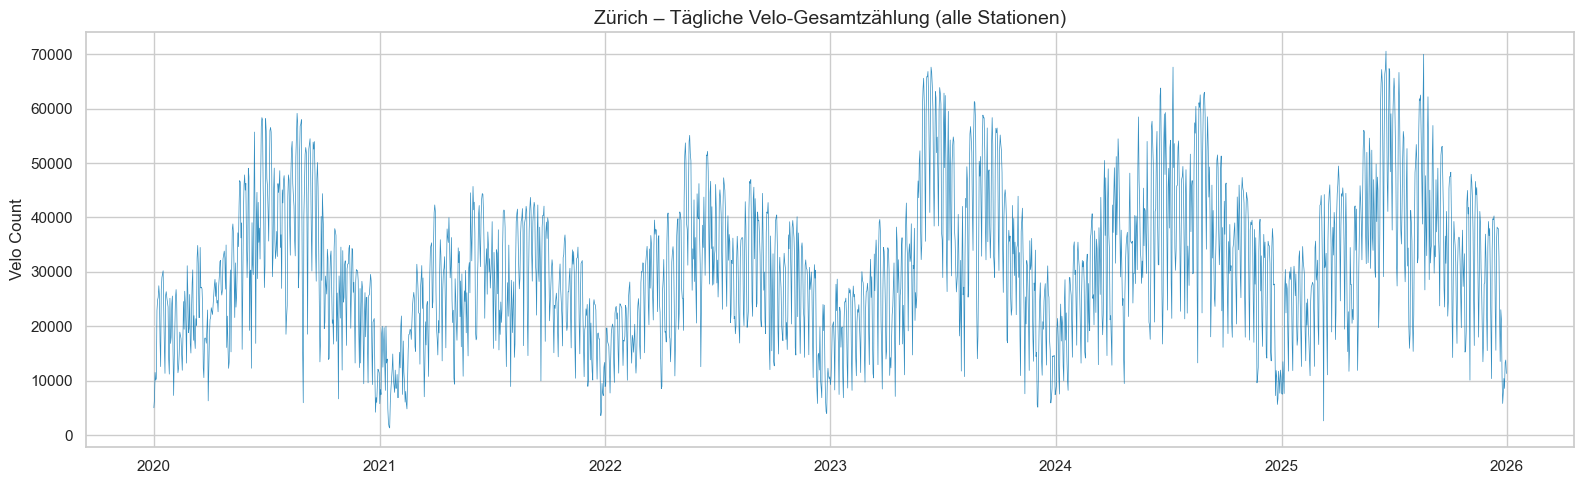

In [15]:
# Daily total velo counts across all stations
daily = zh.groupby(zh['date'].dt.date)['velo_total'].sum()

fig, ax = plt.subplots(figsize=(16, 5))
daily.plot(ax=ax, linewidth=0.5, alpha=0.8)
ax.set_title('Zürich – Tägliche Velo-Gesamtzählung (alle Stationen)', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('Velo Count')
plt.tight_layout()
plt.show()

---
## 1.6 Data Summary

| Dataset | Rows | Time Range | Granularity |
|---------|------|-----------|-------------|
| Zürich  | *see above* | 2020–2025 | 15 min |
| Basel   | *see above* | 2000–now | hourly |
| St. Gallen | *see above* | 2011–now | daily |
| MeteoSwiss | *see above* | varies | hourly |

### Next Steps (Notebook 02)
- Data cleaning & type conversion
- Merge Zürich velo counts with MeteoSwiss weather data on timestamp
- Filter for Velo-only records (exclude pedestrian counts)
- Temporal feature engineering (hour, weekday, month, season, is_holiday)
- Forschungsfragen EDA (FF1–FF4)